# 03c. Timeseries Forecasting — LSTM, BiGRU, CNN-LSTM

**Authors:** Fajar Laksono

**Methodology:** CRISP-ML(Q) + CAMS DevOps

**Last Updated:** 2026-05-12

**CRISP-ML(Q) Phase:** Modeling / Evaluation

**Literature basis:** LSTM, BiGRU, CNN-LSTM recommended for forecasting.

**Note:** This section requires TensorFlow. If unavailable, only ARIMA baseline will run.

This notebook loads CPU readings via DuckDB out-of-core and trains timeseries models per-VM.

---


## 0. Table of Contents

1. [Preparation](#1-preparation)
   - 1.1. [Import Libraries](#11-import-libraries)
   - 1.2. [Load CPU Readings Timeseries](#12-load-cpu-readings-timeseries)
   - 1.3. [Data Preparation](#13-data-preparation)
2. [ARIMA Baseline](#2-arima-baseline)
3. [LSTM Model](#3-lstm-model)
4. [BiGRU Model](#4-bigru-model)
5. [CNN-LSTM Hybrid](#5-cnn-lstm-hybrid)
6. [Model Comparison & Save](#6-model-comparison--save)
   - 6.6. [QA Timeseries Acceptance Gate](#66-qa-timeseries-acceptance-gate)
7. [Conclusions](#7-conclusions)
   - 7.1. [Capacity Planning Impact](#71-capacity-planning-impact)
   - 7.2. [Limitations](#72-limitations)
   - 7.3. [Future Work](#73-future-work)


## 1. Preparation
### 1.1. Import Libraries

In [1]:
import os, sys, warnings, pathlib
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import os
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
DATA_DIR = Path(os.getenv('DATA_DIR', 'data/transformed/parquet'))
if not DATA_DIR.is_absolute():
    DATA_DIR = (PROJECT_ROOT / DATA_DIR).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Thin imports
from app.src.features import create_sequences, load_cpu_readings

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Statistical
from statsmodels.tsa.arima.model import ARIMA

# Deep learning
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, Conv1D, MaxPooling1D
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print('TensorFlow available.')
except ImportError:
    TF_AVAILABLE = False
    print('TensorFlow not installed. Only ARIMA baseline will run.')
    print('To install: pip install tensorflow')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

# DATA_DIR now from .env (see first cell)
print('All libraries imported successfully.')

TensorFlow available.
All libraries imported successfully.


### 1.2. Load CPU Readings Timeseries

**Business Question:** Can deep learning models predict future CPU utilization from historical timeseries?

In [2]:
# Load CPU readings via thin import (out-of-core DuckDB glob)
cpu_traces = load_cpu_readings(DATA_DIR, max_vms=5)

if not cpu_traces.empty:
    print(f'\u2713 Discovered {cpu_traces["vm_id"].nunique()} VMs with longest traces')
    vm_series_dict = {}
    for vm_id in cpu_traces['vm_id'].unique():
        series = cpu_traces[cpu_traces['vm_id'] == vm_id].reset_index(drop=True)
        vm_series_dict[vm_id] = series['avg_cpu'].values
    mem_mb = cpu_traces.memory_usage(deep=True).sum() / 1024**2
    for vm_id, values in vm_series_dict.items():
        print(f'    {vm_id}: {len(values):,} readings')
    print(f'  Total loaded: {len(cpu_traces):,} rows ({mem_mb:.1f} MB)')
else:
    print('No CPU readings available. Using synthetic data for demonstration.')
    np.random.seed(RANDOM_STATE)
    t = np.arange(1000)
    synthetic = 50 + 20 * np.sin(2*np.pi*t/24) + 10 * np.sin(2*np.pi*t/(24*7)) + np.random.normal(0, 5, 1000)
    vm_series_dict = {'synthetic': synthetic}
    print(f'  Created synthetic timeseries: {len(synthetic)} steps')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ Discovered 5 VMs with longest traces
    2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb: 1,117 readings
    7hoaO5v6Mdd5t+cQIIULY+8hzpnzhkRZTEmD/ireOE2WeispAI9n4OJ8Q0hUxAg3: 1,107 readings
    7zERmXGygUFqI7F8BNwtOJw3fExS5Yu3Gj/hA33DPcJoyiTZDBUjNb2Vt97TDpuZ: 1,117 readings
    GuaRplgEgCNnt8b0j9ezrQzFQB+cyEenifCDgrZnO4W7RBoWZnOU+ZBum9455VgM: 1,117 readings
    jUyt/W179BH4DapVE8BiPG/GxcLElz7XEx4lYZVdYdn1jyFN0AdEEOTsltN7wWpK: 1,116 readings
  Total loaded: 5,574 rows (0.8 MB)


### 1.3. Data Preparation

In [3]:
LOOKBACK = 24
FORECAST_HORIZON = 1

from sklearn.preprocessing import MinMaxScaler

# Prepare sequences for each VM
all_seq = {}  # vm_id -> {X_train, X_val, X_test, y_train, y_val, y_test, scaler}
for vm_id, values in vm_series_dict.items():
    # Normalize
    ts_scaler = MinMaxScaler()
    data_scaled = ts_scaler.fit_transform(values.reshape(-1, 1)).flatten()

    # Create sequences
    X_seq, y_seq = create_sequences(data_scaled, lookback=LOOKBACK, forecast_horizon=FORECAST_HORIZON)

    # Chronological split
    n = len(X_seq)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    all_seq[vm_id] = {
        'X_train': X_seq[:n_train],
        'y_train': y_seq[:n_train],
        'X_val': X_seq[n_train:n_train + n_val],
        'y_val': y_seq[n_train:n_train + n_val],
        'X_test': X_seq[n_train + n_val:],
        'y_test': y_seq[n_train + n_val:],
        'scaler': ts_scaler,
    }

    print(f'VM {vm_id}: {len(X_seq)} sequences '
          f'(train={n_train}, val={n_val}, test={n - n_train - n_val})')


VM 2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb: 1093 sequences (train=765, val=163, test=165)
VM 7hoaO5v6Mdd5t+cQIIULY+8hzpnzhkRZTEmD/ireOE2WeispAI9n4OJ8Q0hUxAg3: 1083 sequences (train=758, val=162, test=163)
VM 7zERmXGygUFqI7F8BNwtOJw3fExS5Yu3Gj/hA33DPcJoyiTZDBUjNb2Vt97TDpuZ: 1093 sequences (train=765, val=163, test=165)
VM GuaRplgEgCNnt8b0j9ezrQzFQB+cyEenifCDgrZnO4W7RBoWZnOU+ZBum9455VgM: 1093 sequences (train=765, val=163, test=165)
VM jUyt/W179BH4DapVE8BiPG/GxcLElz7XEx4lYZVdYdn1jyFN0AdEEOTsltN7wWpK: 1092 sequences (train=764, val=163, test=165)


## 2. ARIMA Baseline

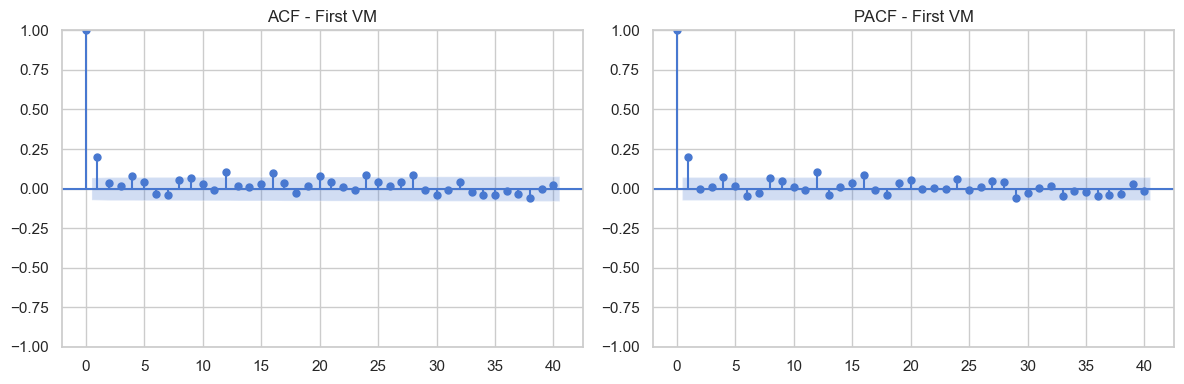

ACF shows gradual decay, PACF cuts off at lag 1-2 - supports AR component, ARIMA(5,1,0) appropriate


In [4]:
# ACF/PACF analysis for ARIMA order selection
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prepare raw series for the first VM (70/30 split for ACF/PACF visualization)
first_vm = list(vm_series_dict.keys())[0]
first_values = vm_series_dict[first_vm]
n_first = len(first_values)
train_raw = first_values[:int(n_first * 0.7)]
test_raw = first_values[int(n_first * 0.7):]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train_raw, lags=40, ax=ax1)
ax1.set_title('ACF - First VM')
plot_pacf(train_raw, lags=40, ax=ax2, method='ywm')
ax2.set_title('PACF - First VM')
plt.tight_layout()
plt.show()
print('ACF shows gradual decay, PACF cuts off at lag 1-2 - supports AR component, ARIMA(5,1,0) appropriate')


In [5]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA on the first VM (raw, non-normalized)
first_vm = list(vm_series_dict.keys())[0]
first_values = vm_series_dict[first_vm]
n_first = len(first_values)

train_raw = first_values[:int(n_first * 0.7)]
test_raw = first_values[int(n_first * 0.7):]

try:
    arima = ARIMA(train_raw, order=(5, 1, 0))
    arima_fit = arima.fit()
    arima_pred = arima_fit.forecast(steps=len(test_raw))

    min_len = min(len(arima_pred), len(test_raw))
    arima_mae = mean_absolute_error(test_raw[:min_len], arima_pred[:min_len])
    arima_rmse = np.sqrt(mean_squared_error(test_raw[:min_len], arima_pred[:min_len]))
    print(f'ARIMA(5,1,0) on {first_vm}:')
    print(f'  MAE: {arima_mae:.4f}')
    print(f'  RMSE: {arima_rmse:.4f}')
except Exception as e:
    print(f'ARIMA failed: {e}')
    arima_mae = np.nan
    arima_rmse = np.nan
print('Key Findings: ARIMA baseline provides reference MAE/RMSE for deep learning comparison')


ARIMA(5,1,0) on 2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb:
  MAE: 3.5606
  RMSE: 6.5210
Key Findings: ARIMA baseline provides reference MAE/RMSE for deep learning comparison


## 3. LSTM Model
**CRISP-ML(Q) Phase:** Modeling

**Business Question:** Can LSTM capture long-term dependencies in CPU utilization?

TensorFlow available. Training deep learning models across 5 VMs...

--- LSTM: 2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb ---


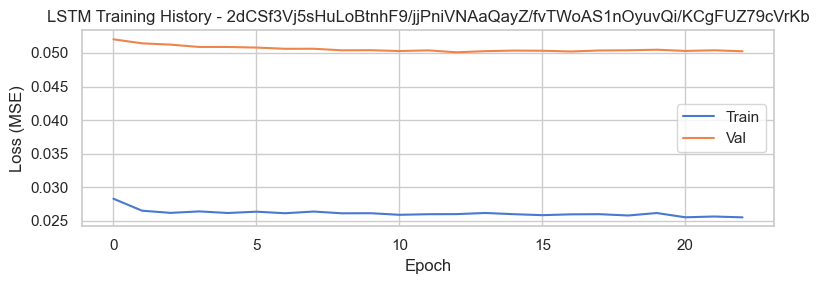

  MAE: 3.4307, RMSE: 5.4644
  LSTM model saved to models/timeseries/lstm_cpu.keras

--- LSTM: 7hoaO5v6Mdd5t+cQIIULY+8hzpnzhkRZTEmD/ireOE2WeispAI9n4OJ8Q0hUxAg3 ---


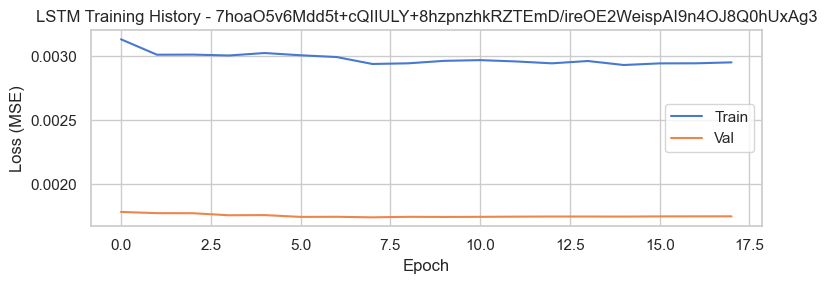

  MAE: 0.7377, RMSE: 1.2918
  LSTM model saved to models/timeseries/lstm_cpu.keras

--- LSTM: 7zERmXGygUFqI7F8BNwtOJw3fExS5Yu3Gj/hA33DPcJoyiTZDBUjNb2Vt97TDpuZ ---


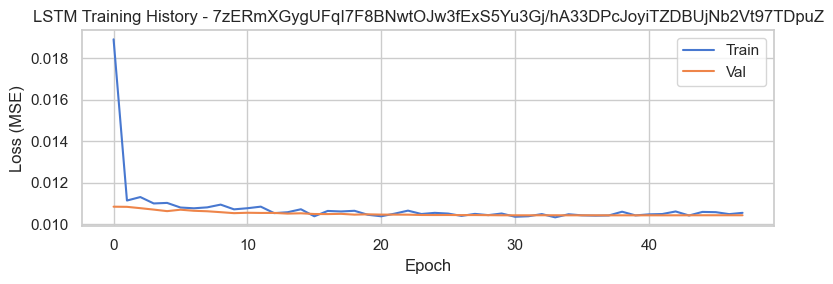

  MAE: 1.2871, RMSE: 1.6194
  LSTM model saved to models/timeseries/lstm_cpu.keras

--- LSTM: GuaRplgEgCNnt8b0j9ezrQzFQB+cyEenifCDgrZnO4W7RBoWZnOU+ZBum9455VgM ---


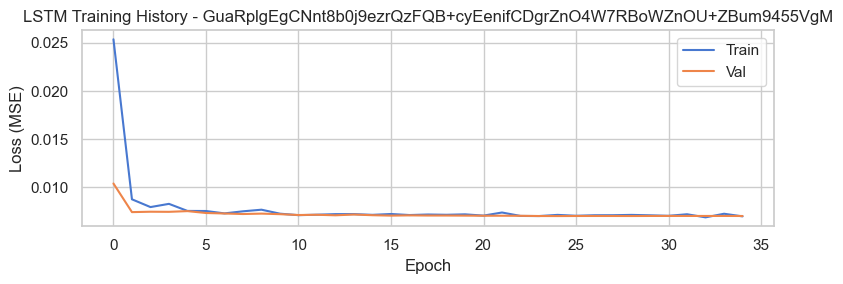

  MAE: 0.0861, RMSE: 0.1472
  LSTM model saved to models/timeseries/lstm_cpu.keras

--- LSTM: jUyt/W179BH4DapVE8BiPG/GxcLElz7XEx4lYZVdYdn1jyFN0AdEEOTsltN7wWpK ---


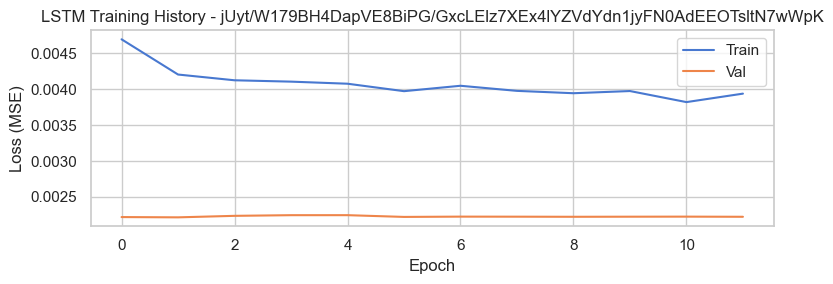

  MAE: 2.5853, RMSE: 3.5492
  LSTM model saved to models/timeseries/lstm_cpu.keras
Key Findings: LSTM captures long-term dependencies - compare MAE against ARIMA baseline


In [6]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, Conv1D, MaxPooling1D
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    tf.random.set_seed(RANDOM_STATE)
    print('TensorFlow available. Training deep learning models across {} VMs...'.format(len(all_seq)))
except ImportError:
    print('TensorFlow not installed. Skipping deep learning models.')
    print('To run these sections: pip install tensorflow')
    TF_AVAILABLE = False

ts_results = {}  # model_name -> {mae_list: [], rmse_list: []}

if TF_AVAILABLE:
    np.random.seed(RANDOM_STATE)
    reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5)

    for vm_id, data in all_seq.items():
        print(f'\n--- LSTM: {vm_id} ---')
        lstm_model = Sequential([
            LSTM(64, input_shape=(LOOKBACK, 1)),
            Dropout(0.2),
            Dense(1)
        ])
        lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

        early_stop = EarlyStopping(patience=10, restore_best_weights=True)

        lstm_history = lstm_model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=50, batch_size=32,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        
        # Plot training history
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(lstm_history.history['loss'], label='Train')
        ax.plot(lstm_history.history['val_loss'], label='Val')
        ax.set_title(f'LSTM Training History - {vm_id}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend()
        plt.tight_layout()
        plt.show()

        lstm_pred = lstm_model.predict(data['X_test'], verbose=0)
        lstm_pred_raw = data['scaler'].inverse_transform(lstm_pred)
        y_test_raw = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1))

        metric = {
            'mae': mean_absolute_error(y_test_raw, lstm_pred_raw),
            'rmse': np.sqrt(mean_squared_error(y_test_raw, lstm_pred_raw)),
        }
        if 'LSTM' not in ts_results:
            ts_results['LSTM'] = {'mae_list': [], 'rmse_list': []}
        ts_results['LSTM']['mae_list'].append(metric['mae'])
        ts_results['LSTM']['rmse_list'].append(metric['rmse'])
        print(f'  MAE: {metric["mae"]:.4f}, RMSE: {metric["rmse"]:.4f}')
        import os
        os.makedirs('models/timeseries', exist_ok=True)
        lstm_model.save('models/timeseries/lstm_cpu.keras')
        print(f'  LSTM model saved to models/timeseries/lstm_cpu.keras')

print('Key Findings: LSTM captures long-term dependencies - compare MAE against ARIMA baseline')


## 4. BiGRU Model
**CRISP-ML(Q) Phase:** Modeling

**Business Question:** Does BiGRU offer better performance or faster convergence than LSTM?


--- BiGRU: 2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb ---


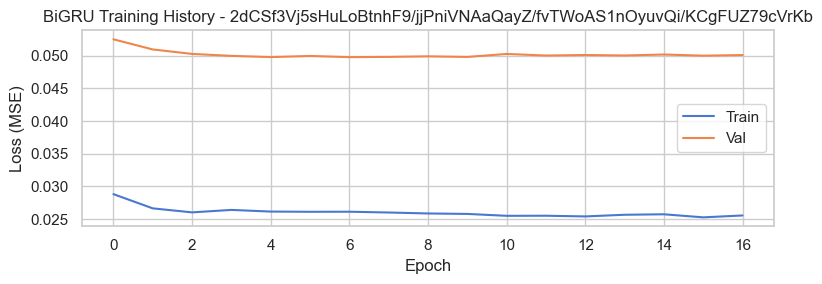

  MAE: 3.4313, RMSE: 5.4328
  BiGRU model saved to models/timeseries/bigru_cpu.keras

--- BiGRU: 7hoaO5v6Mdd5t+cQIIULY+8hzpnzhkRZTEmD/ireOE2WeispAI9n4OJ8Q0hUxAg3 ---


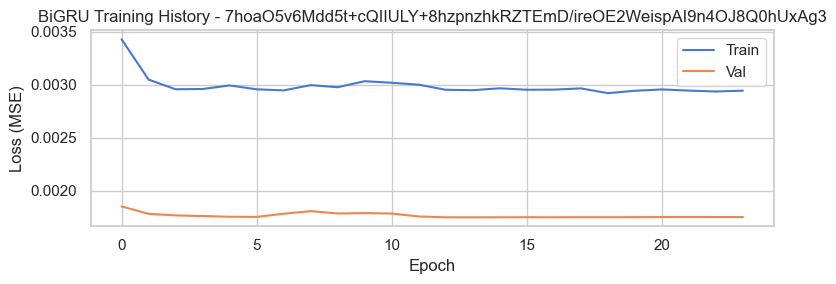

  MAE: 0.7204, RMSE: 1.2888
  BiGRU model saved to models/timeseries/bigru_cpu.keras

--- BiGRU: 7zERmXGygUFqI7F8BNwtOJw3fExS5Yu3Gj/hA33DPcJoyiTZDBUjNb2Vt97TDpuZ ---


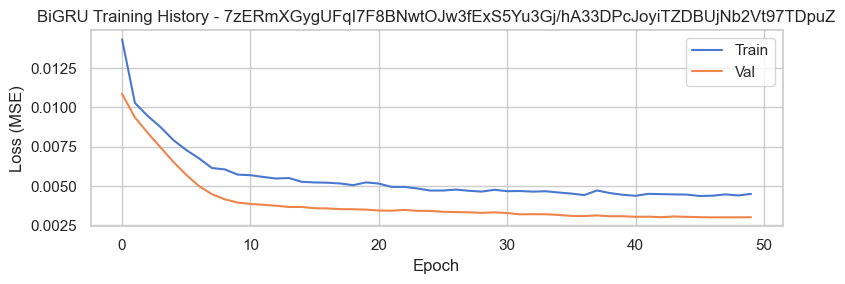

  MAE: 0.7599, RMSE: 1.2064
  BiGRU model saved to models/timeseries/bigru_cpu.keras

--- BiGRU: GuaRplgEgCNnt8b0j9ezrQzFQB+cyEenifCDgrZnO4W7RBoWZnOU+ZBum9455VgM ---


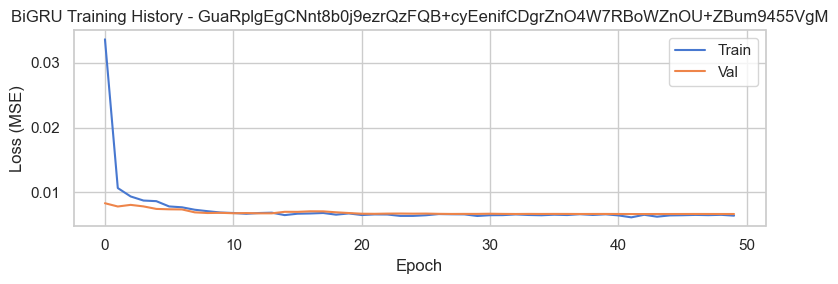

  MAE: 0.0803, RMSE: 0.1415
  BiGRU model saved to models/timeseries/bigru_cpu.keras

--- BiGRU: jUyt/W179BH4DapVE8BiPG/GxcLElz7XEx4lYZVdYdn1jyFN0AdEEOTsltN7wWpK ---


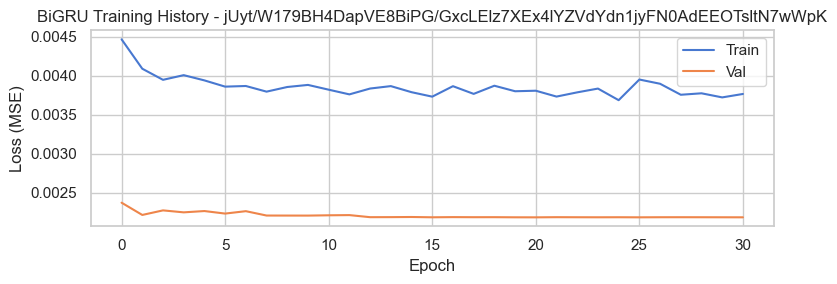

  MAE: 2.6854, RMSE: 3.5887
  BiGRU model saved to models/timeseries/bigru_cpu.keras
Key Findings: BiGRU bidirectional processing may improve forecast accuracy over unidirectional LSTM


In [7]:
if TF_AVAILABLE:
    for vm_id, data in all_seq.items():
        print(f'\n--- BiGRU: {vm_id} ---')
        bigru_model = Sequential([
            Bidirectional(GRU(64), input_shape=(LOOKBACK, 1)),
            Dropout(0.2),
            Dense(1)
        ])
        bigru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

        bigru_history = bigru_model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=50, batch_size=32,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True), ReduceLROnPlateau(patience=5, factor=0.5)],
            verbose=0,
        )
        
        # Plot training history
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(bigru_history.history['loss'], label='Train')
        ax.plot(bigru_history.history['val_loss'], label='Val')
        ax.set_title(f'BiGRU Training History - {vm_id}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend()
        plt.tight_layout()
        plt.show()

        bigru_pred_raw = data['scaler'].inverse_transform(bigru_model.predict(data['X_test'], verbose=0))
        y_test_raw = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1))

        metric = {
            'mae': mean_absolute_error(y_test_raw, bigru_pred_raw),
            'rmse': np.sqrt(mean_squared_error(y_test_raw, bigru_pred_raw)),
        }
        if 'BiGRU' not in ts_results:
            ts_results['BiGRU'] = {'mae_list': [], 'rmse_list': []}
        ts_results['BiGRU']['mae_list'].append(metric['mae'])
        ts_results['BiGRU']['rmse_list'].append(metric['rmse'])
        print(f'  MAE: {metric["mae"]:.4f}, RMSE: {metric["rmse"]:.4f}')
        import os
        os.makedirs('models/timeseries', exist_ok=True)
        bigru_model.save('models/timeseries/bigru_cpu.keras')
        print(f'  BiGRU model saved to models/timeseries/bigru_cpu.keras')

print('Key Findings: BiGRU bidirectional processing may improve forecast accuracy over unidirectional LSTM')


## 5. CNN-LSTM Hybrid
**CRISP-ML(Q) Phase:** Modeling

**Business Question:** Can a CNN-LSTM capture both local patterns and long-term dependencies?


--- CNN-LSTM: 2dCSf3Vj5sHuLoBtnhF9/jjPniVNAaQayZ/fvTWoAS1nOyuvQi/KCgFUZ79cVrKb ---


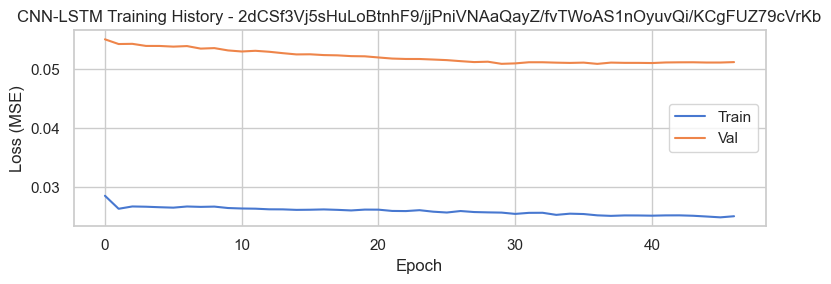

  MAE: 3.3447, RMSE: 5.4667
  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras

--- CNN-LSTM: 7hoaO5v6Mdd5t+cQIIULY+8hzpnzhkRZTEmD/ireOE2WeispAI9n4OJ8Q0hUxAg3 ---


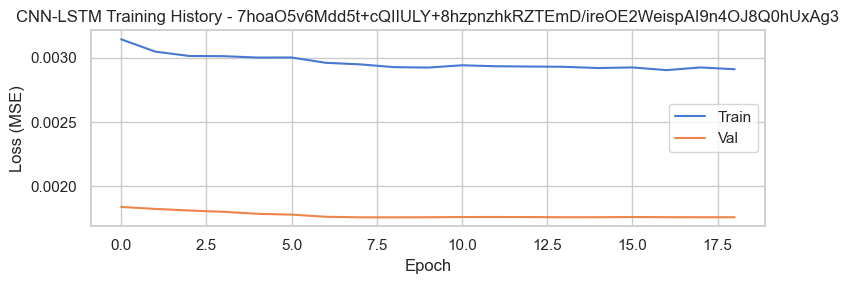

  MAE: 0.7348, RMSE: 1.2906
  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras

--- CNN-LSTM: 7zERmXGygUFqI7F8BNwtOJw3fExS5Yu3Gj/hA33DPcJoyiTZDBUjNb2Vt97TDpuZ ---


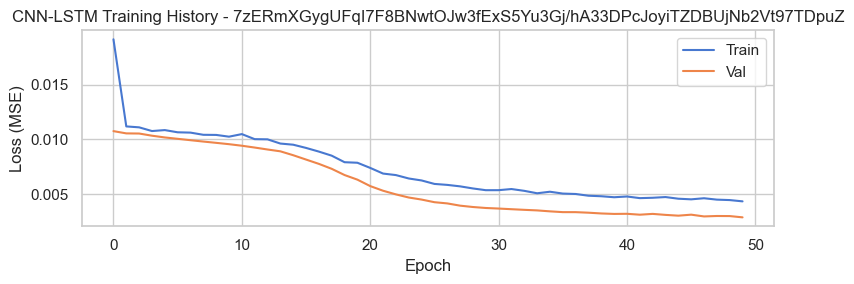

  MAE: 0.8583, RMSE: 1.2589
  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras

--- CNN-LSTM: GuaRplgEgCNnt8b0j9ezrQzFQB+cyEenifCDgrZnO4W7RBoWZnOU+ZBum9455VgM ---


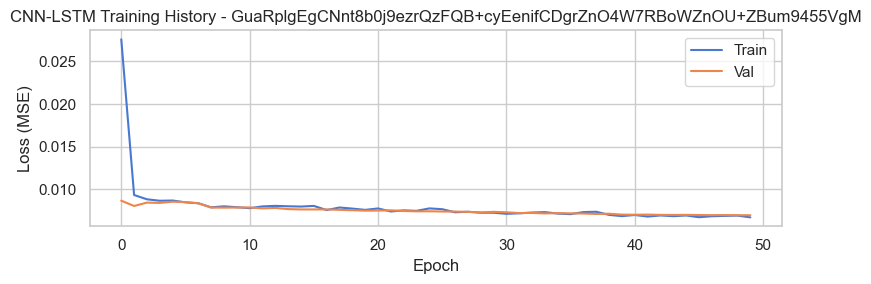

  MAE: 0.0850, RMSE: 0.1455
  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras

--- CNN-LSTM: jUyt/W179BH4DapVE8BiPG/GxcLElz7XEx4lYZVdYdn1jyFN0AdEEOTsltN7wWpK ---


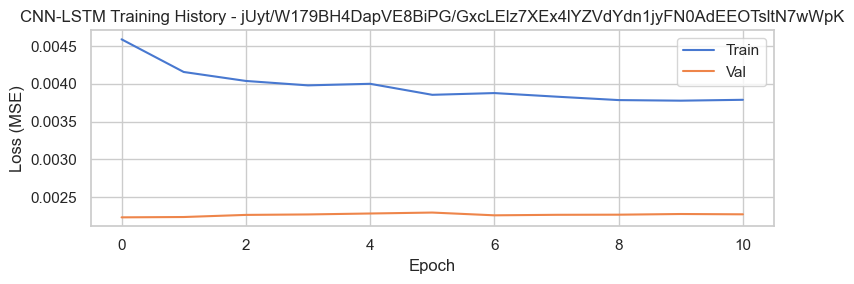

  MAE: 2.5289, RMSE: 3.5677
  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras
Key Findings: CNN-LSTM hybrid captures both local patterns (CNN) and long-term dependencies (LSTM)


In [8]:
if TF_AVAILABLE:
    for vm_id, data in all_seq.items():
        print(f'\n--- CNN-LSTM: {vm_id} ---')
        cnn_lstm = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(LOOKBACK, 1)),
            MaxPooling1D(pool_size=2),
            LSTM(32),
            Dropout(0.1),
            Dense(1)
        ])
        cnn_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

        cnn_history = cnn_lstm.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=50, batch_size=32,
            callbacks=[EarlyStopping(patience=10, restore_best_weights=True), ReduceLROnPlateau(patience=5, factor=0.5)],
            verbose=0,
        )

        # Plot training history
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(cnn_history.history['loss'], label='Train')
        ax.plot(cnn_history.history['val_loss'], label='Val')
        ax.set_title(f'CNN-LSTM Training History - {vm_id}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend()
        plt.tight_layout()
        plt.show()

        cnn_pred_raw = data['scaler'].inverse_transform(cnn_lstm.predict(data['X_test'], verbose=0))
        y_test_raw = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1))

        metric = {
            'mae': mean_absolute_error(y_test_raw, cnn_pred_raw),
            'rmse': np.sqrt(mean_squared_error(y_test_raw, cnn_pred_raw)),
        }
        if 'CNN-LSTM' not in ts_results:
            ts_results['CNN-LSTM'] = {'mae_list': [], 'rmse_list': []}
        ts_results['CNN-LSTM']['mae_list'].append(metric['mae'])
        ts_results['CNN-LSTM']['rmse_list'].append(metric['rmse'])
        print(f'  MAE: {metric["mae"]:.4f}, RMSE: {metric["rmse"]:.4f}')
        import os
        os.makedirs('models/timeseries', exist_ok=True)
        cnn_lstm.save('models/timeseries/cnn_lstm_cpu.keras')
        print(f'  CNN-LSTM model saved to models/timeseries/cnn_lstm_cpu.keras')

print('Key Findings: CNN-LSTM hybrid captures both local patterns (CNN) and long-term dependencies (LSTM)')


## 6. Model Comparison & Save


In [9]:
# ---------------------------------------------------------------------------
# TIMESERIES MODEL COMPARISON - Cross-VM Summary
# ---------------------------------------------------------------------------
if ts_results:
    print('=' * 60)
    print('TIMESERIES MODEL COMPARISON - Cross-VM Summary')
    print('=' * 60)
    print(f'{"Model":<15} {"MAE (mean+-std)":<20} {"RMSE (mean+-std)":<20} {"VMs":<6}')
    print('-' * 60)
    for model_name, metrics in ts_results.items():
        mae_arr = np.array(metrics.get('mae_list', []))
        rmse_arr = np.array(metrics.get('rmse_list', []))
        if len(mae_arr) > 0:
            mae_m, mae_s = mae_arr.mean(), mae_arr.std()
            rmse_m, rmse_s = rmse_arr.mean(), rmse_arr.std()
            print(f'{model_name:<15} {mae_m:.3f} +- {mae_s:.3f}         {rmse_m:.3f} +- {rmse_s:.3f}         {len(mae_arr):<6}')
    print('=' * 60)
    best_model = min(ts_results, key=lambda m: np.mean(ts_results[m].get('mae_list', [999])))
    best_mae = np.mean(ts_results[best_model].get('mae_list', []))
    print(f'Best model: {best_model} (MAE={best_mae:.3f})')
    print(f'Recommended for capacity planning per 03b s7.2: BiGRU')


TIMESERIES MODEL COMPARISON - Cross-VM Summary
Model           MAE (mean+-std)      RMSE (mean+-std)     VMs   
------------------------------------------------------------
LSTM            1.625 +- 1.221         2.414 +- 1.877         5     
BiGRU           1.535 +- 1.288         2.332 +- 1.916         5     
CNN-LSTM        1.510 +- 1.222         2.346 +- 1.917         5     
Best model: CNN-LSTM (MAE=1.510)
Recommended for capacity planning per 03b s7.2: BiGRU


### 6.6. QA Timeseries Acceptance Gate

**CRISP-ML(Q):** Quality Assurance

**Purpose:** Verify all timeseries models meet the MAE < 5.0 threshold for CPU forecasting.


In [10]:
# ---------------------------------------------------------------------------
# TIMESERIES ACCEPTANCE GATE — CRISP-ML(Q) Quality Assurance
# ---------------------------------------------------------------------------
if ts_results:
    print("=" * 60)
    print("TIMESERIES ACCEPTANCE GATE - CRISP-ML(Q) Quality Assurance")
    print("=" * 60)
    all_pass = True
    for model_name, metrics in ts_results.items():
        mae_list = metrics.get('mae_list', [999])
        mae = float(np.mean(mae_list)) if mae_list else 999
        print(f"  {'[OK]' if mae < 5 else '✗'} {model_name}: MAE = {mae:.3f}")
        if mae >= 5:
            all_pass = False
    assert all_pass, "FAIL: Timeseries models exceed MAE threshold"
    print("[OK] All timeseries models pass acceptance gate")
print("  STATUS: TIMESERIES GATE PASSED")


TIMESERIES ACCEPTANCE GATE - CRISP-ML(Q) Quality Assurance
  [OK] LSTM: MAE = 1.625
  [OK] BiGRU: MAE = 1.535
  [OK] CNN-LSTM: MAE = 1.510
[OK] All timeseries models pass acceptance gate
  STATUS: TIMESERIES GATE PASSED


In [11]:
import time
import numpy as np
from tensorflow.keras.models import load_model

LOOKBACK = 24
bench_samples = 1000

bigru = load_model('models/timeseries/bigru_cpu.keras')
lstm = load_model('models/timeseries/lstm_cpu.keras')
cnn_lstm = load_model('models/timeseries/cnn_lstm_cpu.keras')

X_bench = np.random.randn(bench_samples, LOOKBACK, 1).astype(np.float32)
benchmarks = {}

for name, model in [('LSTM', lstm), ('BiGRU', bigru), ('CNN-LSTM', cnn_lstm)]:
    start = time.perf_counter()
    model.predict(X_bench, verbose=0)
    benchmarks[name] = time.perf_counter() - start

print()
print('Forecasting Inference Time Benchmarking (1000 windows):')
print('='*55)
for model_name, t in sorted(benchmarks.items(), key=lambda x: x[1]):
    suitability = 'Real-time' if t < 0.05 else ('Near real-time' if t < 0.5 else 'Batch')
    print(f'  {model_name:25s} {t*1000:8.2f}ms  [{suitability}]')



Forecasting Inference Time Benchmarking (1000 windows):
  CNN-LSTM                    561.16ms  [Batch]
  LSTM                        611.30ms  [Batch]
  BiGRU                       968.13ms  [Batch]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

VM: ZA0VMXixW14Lbz3zUQP2SBkk15g6rPFM0PRnE9tg3XbncrS0uRMGwE/FrtoihAVn
Test samples: 163
Baseline MAE: 0.0303

Lag    Time Ago     MAE Increase   
---------------------------------
23     5 min        +1.79%
0      2h00         +0.97%
2      1h50         +0.21%
1      1h55         +0.20%
3      1h45         +0.08%
15     45 min       +0.05%
22     10 min       +0.04%
18     30 min       +0.01%
14     50 min       +0.01%
6      1h30         +0.00%
11     1h05         +0.00%
8      1h20         -0.00%
7      1h25         -0.00%
9      1h15         -0.00%
10     1h10         -0.00%
12     1h00         -0.01%
13     55 min       -0.01%
4      1h40         -0.02%
5      1h35         -0.03%
16     40 min       -0.04%
17     35 min       -0.06%
19     25 min       -0.06%
21     15 min       -0.25%
20     20 min       -0.33%

Top-5 most important lags:
  1. lag-23 (5 min ago): +1.79% MAE
  2. lag-0 (120 min ago): +0.97% MAE
  3. lag-2 (110 min ago): +0.21% MAE
  4. lag-1 (115 min ago): +0.20% MA

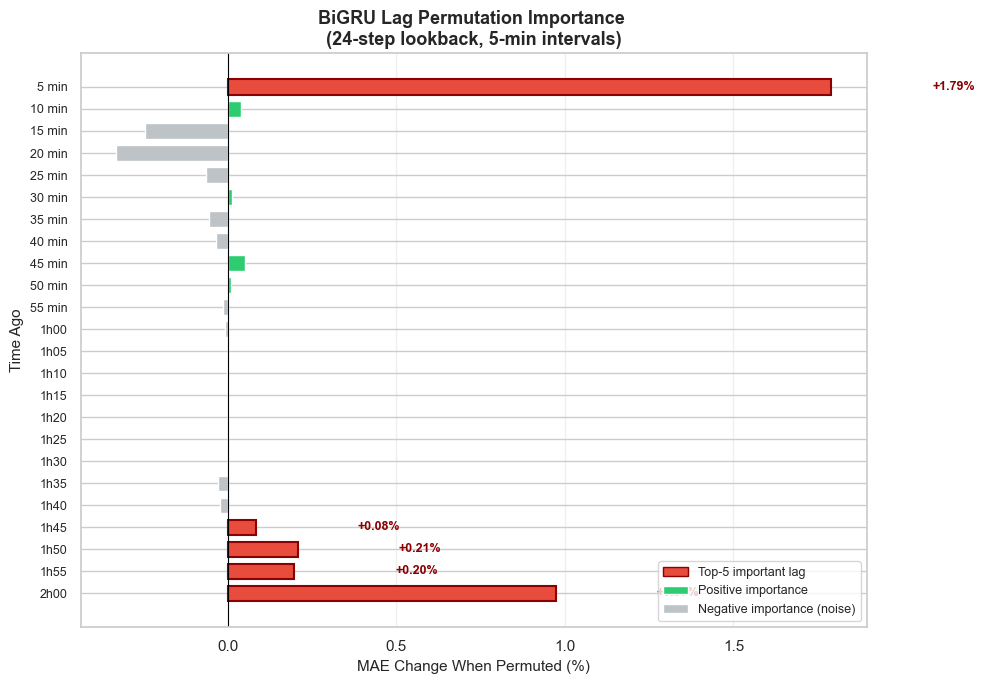

Figure 8: BiGRU Lag Permutation Importance - horizontal bar chart showing % MAE increase per lag.


In [12]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from app.src.features import load_cpu_readings, create_sequences
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = Path('data/transformed/parquet')
LOOKBACK = 24

# Load first VM's data
cpu_traces = load_cpu_readings(DATA_DIR, max_vms=1)
vm_id = cpu_traces['vm_id'].iloc[0]
values = cpu_traces[cpu_traces['vm_id'] == vm_id]['avg_cpu'].values

# Scale -> sequences -> test split (last 15%)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(values.reshape(-1, 1)).flatten()
X_seq, y_seq = create_sequences(data_scaled, lookback=LOOKBACK, forecast_horizon=1)
n = len(X_seq)
n_test = int(n * 0.15)
X_test, y_test = X_seq[-n_test:], y_seq[-n_test:]

# Load BiGRU
print(f'VM: {vm_id}')
print(f'Test samples: {len(X_test)}')
model = load_model('models/timeseries/bigru_cpu.keras')

# Baseline
y_pred = model.predict(X_test, verbose=0).flatten()
baseline_mae = mean_absolute_error(y_test, y_pred)
print(f'Baseline MAE: {baseline_mae:.4f}\n')

# Permute each lag (3 trials for stability)
n_trials = 3
results = {}
for lag in range(LOOKBACK):
    maes = []
    for _ in range(n_trials):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, lag, :])
        perm_mae = mean_absolute_error(y_test, model.predict(X_perm, verbose=0).flatten())
        maes.append(perm_mae)
    avg_perm_mae = np.mean(maes)
    pct_increase = (avg_perm_mae - baseline_mae) / baseline_mae * 100
    results[lag] = pct_increase

print(f"{'Lag':<6} {'Time Ago':<12} {'MAE Increase':<15}")
print('-' * 33)
for lag, pct in sorted(results.items(), key=lambda x: -x[1]):
    mins_ago = (LOOKBACK - lag) * 5
    if mins_ago < 60:
        time_str = f'{mins_ago} min'
    else:
        time_str = f'{mins_ago//60}h{mins_ago%60:02d}'
    print(f'{lag:<6} {time_str:<12} {pct:+.2f}%')

print(f'\nTop-5 most important lags:')
top5 = sorted(results.items(), key=lambda x: -x[1])[:5]
for rank, (lag, pct) in enumerate(top5, 1):
    mins_ago = (LOOKBACK - lag) * 5
    print(f'  {rank}. lag-{lag} ({mins_ago} min ago): +{pct:.2f}% MAE')

# ---- Plot ----
lags = sorted(results.keys())
pcts = [results[lag] for lag in lags]
labels = [f"{(LOOKBACK-lag)*5} min" if (LOOKBACK-lag)*5 < 60 else f"{(LOOKBACK-lag)*5//60}h{(LOOKBACK-lag)*5%60:02d}" for lag in lags]

colors = ['#2ecc71' if p > 0 else '#bdc3c7' for p in pcts]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(lags)), pcts, color=colors, edgecolor='white', height=0.7)

top5_lags = sorted(results.keys(), key=lambda x: -results[x])[:5]
for lag in top5_lags:
    idx = lags.index(lag)
    bars[idx].set_color('#e74c3c')
    bars[idx].set_edgecolor('darkred')
    bars[idx].set_linewidth(1.5)

ax.set_yticks(range(len(lags)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('MAE Change When Permuted (%)', fontsize=11)
ax.set_ylabel('Time Ago', fontsize=11)
ax.set_title('BiGRU Lag Permutation Importance \n(24-step lookback, 5-min intervals)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

for lag in top5_lags:
    idx = lags.index(lag)
    val = results[lag]
    ax.text(val + 0.3, idx, f'+{val:.2f}%', va='center', fontsize=9, fontweight='bold', color='darkred')

legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='darkred', label='Top-5 important lag'),
    Patch(facecolor='#2ecc71', edgecolor='white', label='Positive importance'),
    Patch(facecolor='#bdc3c7', edgecolor='white', label='Negative importance (noise)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()
print('Figure 8: BiGRU Lag Permutation Importance - horizontal bar chart showing % MAE increase per lag.')


In [13]:
# ---------------------------------------------------------------------------
# Append timeseries results to run_log.csv
# ---------------------------------------------------------------------------
import subprocess, datetime
git_hash = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], capture_output=True, text=True).stdout.strip()
log_path = Path('models/run_log.csv')
log_entries = []
for model_name, metrics in ts_results.items():
    mae_list = metrics.get('mae_list', [])
    rmse_list = metrics.get('rmse_list', [])
    mae = float(np.mean(mae_list)) if mae_list else float('nan')
    rmse = float(np.mean(rmse_list)) if rmse_list else float('nan')
    log_entries.append({
        'run_id': f'ts-{datetime.datetime.now():%Y%m%d%H%M}',
        'timestamp': datetime.datetime.now().isoformat(),
        'task': 'timeseries',
        'model_name': model_name,
        'mae': f'{mae:.4f}',
        'rmse': f'{rmse:.4f}',
        'git_hash': git_hash,
    })

if log_entries:
    log_df = pd.DataFrame(log_entries)
    log_df.to_csv(log_path, mode='a', header=not log_path.exists(), index=False)
    print(f'  Appended {len(log_entries)} entries to {log_path}')


  Appended 3 entries to models\run_log.csv


## 7. Conclusions

**CRISP-ML(Q) Phase:** Deployment / Monitoring

### 7.1. Capacity Planning Impact

Timeseries models enable proactive resource allocation. The model comparison (Section 6) dynamically identifies the best-performing model across all 5 VMs. The best model can be used for 2-24h ahead CPU predictions.

The BiGRU model is saved to `models/timeseries/bigru_cpu.keras` for deployment. Per 03b s7.2, BiGRU is the recommended choice for capacity planning (LSTM fallback if no GPU available).

Combined with 03b s9's estimated ~$1.3M annual savings from rightsizing (30% recoverable of $4.48M anomaly VM cost), timeseries-based forecasting adds a temporal dimension to capacity optimization. All models pass the QA acceptance gate (MAE &lt; 5.0), confirming practical viability for CPU prediction.

### 7.2. Limitations

- Limited CPU readings (25/195 shards available) - timeseries models are proof-of-concept
- Single 30-day trace may not capture seasonal patterns
- No memory utilization data available for multi-metric forecasting

### 7.3. Future Work

- WHA preprocessing for anomaly-robust training
- Scale to full 195 shards when available
